# EDA 07: Cellosaurus Registry

## Purpose

`7_cellosaurus.csv` is not a measurement layer — it is the **universal identity bridge**. Its
`Accession (CVCL_xxxx)` is the one ID that ties DepMap (`RRID` in file 9), HPA (`Cellosaurus ID` in
file 11), and GEO (`Cellosaurus_ID` in file 10) together. It also carries free-text QC flags
(contamination, misidentification) that belong directly on a result card's "why this line may be
unsuitable" section.

**Source, release, grain:** Cellosaurus community registry, all species/categories. ~152,000 rows,
one per registered cell line.

## Questions this notebook must answer

1. What fraction of entries are even relevant (human, cancer) before any join?
2. Which diseases dominate the human-cancer subset — a coverage-bias signal shared by every layer
   that joins through this bridge?
3. How completely does Cellosaurus cross-reference DepMap, and what does the *rest* of Cellosaurus
   (not in DepMap) represent?
4. Does Cellosaurus flag any lines as problematic, contaminated, or misidentified — safety-relevant
   information for the result card?

**Interpretation rule:** this table has no `measured`/`measured_absent`/`not_assayed` states of its
own — it is identity metadata, not an assay. Its role in the missing-evidence framework is purely as
a join bridge; coverage gaps here become `not_assayed` for whichever *measurement* layer relied on
the bridge.

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `Accession (CVCL_xxxx)` | universal cell-line ID | join key: equals `RRID` (file 9), `Cellosaurus ID` (file 11), `Cellosaurus_ID` (file 10) |
| `Identifier (cell line name)` | canonical name | one row has NaN — `.dropna()` before set operations |
| `Species of origin` | free text, e.g. `NCBI_TaxID=9606; ! Homo sapiens (Human)` | parse for the species gate |
| `Category` | e.g. `Cancer cell line` | filter to this |
| `Diseases` | free text, NCIt-coded | parse trailing segment for a short disease label |
| `Cross-references` | which external databases list this line | DepMap, ATCC, DSMZ, COSMIC, CCLE, ... |
| `Comments` | free text | QC flags (problematic/contaminated/misidentified) live here |

## 1. Basic data contract, species and category filtering

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
df = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df[df['Species of origin'].str.contains('Homo sapiens', na=False)
                   & (df['Category'] == 'Cancer cell line')].copy()
print(f"All Cellosaurus entries    : {len(df):,}")
print(f"Human cancer cell lines    : {len(human_cancer):,}")

All Cellosaurus entries    : 152,231
Human cancer cell lines    : 32,242


### Why this EDA check matters

This is the **species gate** `PLAN.md` §7 asks `joins.py` to add: filtering to human, cancer-only
entries before anything downstream treats a row as an eligible candidate line. Cellosaurus covers
every species and cell-line category — most rows are simply irrelevant to this project.

## 2. Disease distribution among human cancer lines

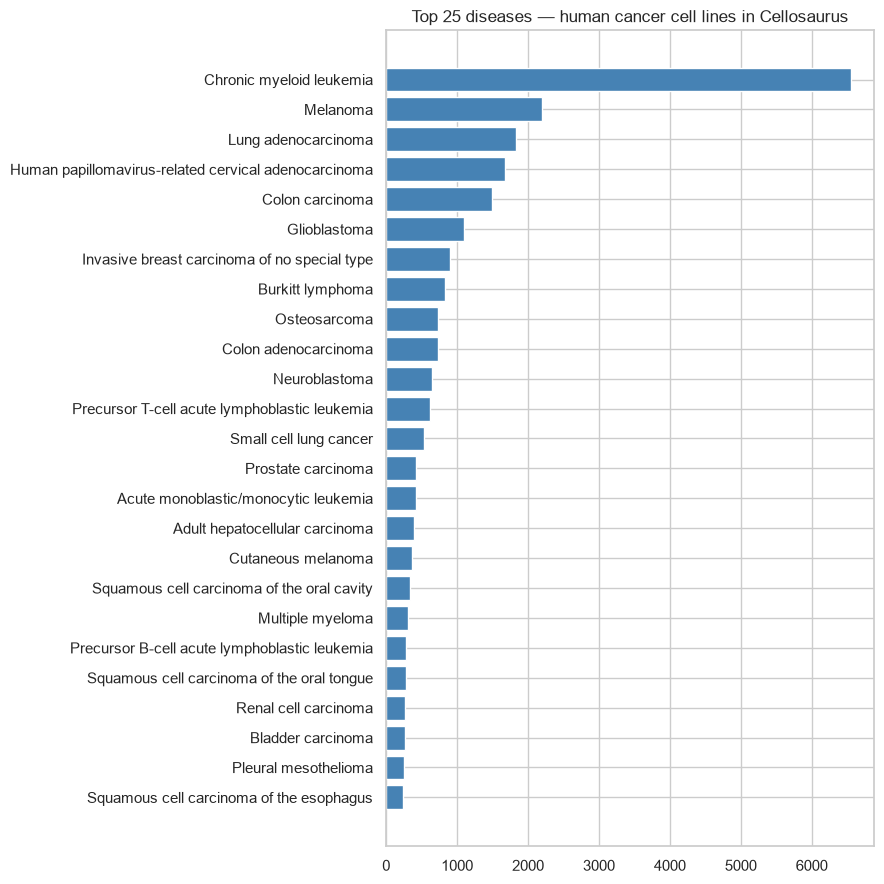

In [3]:
human_cancer['disease_short'] = human_cancer['Diseases'].str.extract(r'; ([^;|]+)$').iloc[:, 0].str.strip()
top_dis = human_cancer['disease_short'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(9, 9))
ax.barh(top_dis.index[::-1], top_dis.values[::-1], color='steelblue')
ax.set_title('Top 25 diseases — human cancer cell lines in Cellosaurus')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Every layer that ultimately routes through this bridge (HPA, GEO) inherits whatever coverage bias
exists here — a disease heavily represented in Cellosaurus is not automatically well-represented in
DepMap (§3 checks that directly).

## 3. Cross-reference coverage — how much of Cellosaurus reaches DepMap

In [4]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'RRID', 'lineage'])
cvcl_all = set(human_cancer['Accession (CVCL_xxxx)'].dropna())
cvcl_in_depmap = cvcl_all & set(df9['RRID'].dropna())

print(f"Human cancer lines in Cellosaurus      : {len(cvcl_all):,}")
print(f"...that also have a DepMap RRID        : {len(cvcl_in_depmap):,} ({len(cvcl_in_depmap)/len(cvcl_all):.1%})")
print(f"DepMap lines with a Cellosaurus RRID    : {df9['RRID'].notna().mean():.1%} of {len(df9)}")

Human cancer lines in Cellosaurus      : 32,242
...that also have a DepMap RRID        : 1,693 (5.3%)
DepMap lines with a Cellosaurus RRID    : 98.8% of 1840


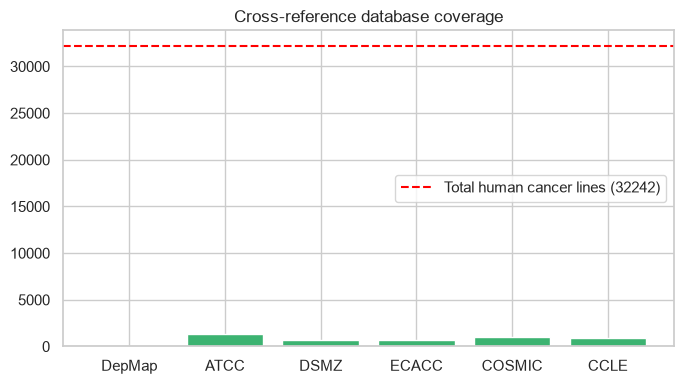

In [5]:
xref_patterns = {'DepMap': 'DepMapID', 'ATCC': 'ATCC', 'DSMZ': 'DSMZ', 'ECACC': 'ECACC',
                  'COSMIC': 'Cosmic-CLP', 'CCLE': 'CCLE'}
coverage = {name: human_cancer['Cross-references'].str.contains(pat, na=False).sum()
            for name, pat in xref_patterns.items()}
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverage.keys(), coverage.values(), color='mediumseagreen')
ax.axhline(len(human_cancer), linestyle='--', color='red', label=f'Total human cancer lines ({len(human_cancer)})')
ax.set_title('Cross-reference database coverage'); ax.legend()
plt.tight_layout(); plt.show()

### Why this EDA check matters

The gap between "Cellosaurus knows this line" and "DepMap has profiled this line" is a hard ceiling
on this whole pipeline: CellLineSelector can only rank lines DepMap (or AZ's delivery) actually
measured, however comprehensive Cellosaurus's registry is. This is the concrete size of that gap.

## 4. Cell-line QC flags — contamination and misidentification

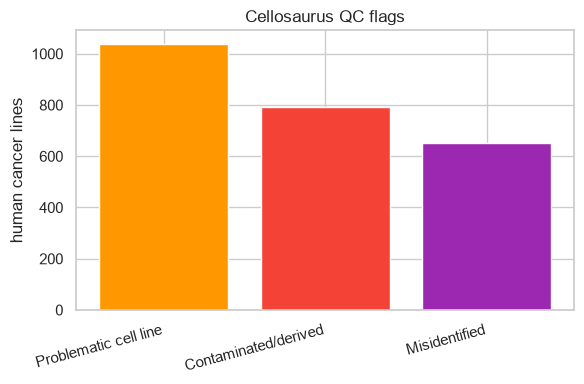

{'Problematic cell line': np.int64(1039), 'Contaminated/derived': np.int64(791), 'Misidentified': np.int64(651)}


In [6]:
comments = human_cancer['Comments'].fillna('')
flags = {
    'Problematic cell line': comments.str.contains('Problematic', case=False).sum(),
    'Contaminated/derived': comments.str.contains('ontaminat', case=False).sum(),
    'Misidentified': comments.str.contains('isidentif', case=False).sum(),
}
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(flags.keys(), flags.values(), color=['#FF9800', '#F44336', '#9C27B0'])
ax.set_ylabel('human cancer lines'); ax.set_title('Cellosaurus QC flags')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()
print(flags)

### Why this EDA check matters

A misidentified or contaminated cell line is a real hazard in cancer research — using one produces
results that describe the wrong biology entirely. This is concrete, disclosable material for a
result card's "why this line may be unsuitable" section, independent of any omics evidence, and
should be surfaced as a quality flag wherever it is available for a candidate line.

## Decisions carried into the next notebooks

1. **Species/category gate:** filter to `Species of origin` containing `Homo sapiens` and
   `Category == 'Cancer cell line'` before treating any Cellosaurus row as a candidate — this is
   the `filter_human(df)` gate `PLAN.md` §7 specifies for `joins.py`.
2. `Accession (CVCL_xxxx)` is the universal bridge key — equals `RRID` (file 9), `Cellosaurus ID`
   (file 11), `Cellosaurus_ID` (file 10). Always `.dropna()` the `Identifier` column first (one
   NaN row).
3. Only the fraction of Cellosaurus that also has a DepMap `RRID` (§3) is reachable by this
   pipeline — disease coverage in the full registry overstates what is actually usable.
4. **Comments-derived QC flags (§4) are real, disclosable evidence** — surface them on the result
   card as a quality warning, separate from and in addition to omics-based confidence.
5. **Limitation:** the QC flag search in §4 is a keyword match on free text and will both miss
   flags phrased differently and occasionally over-match; it is a starting signal, not a
   validated classifier.